iter 0, loss 104.3597
iter 100, loss 111.4868
iter 200, loss 110.5978
iter 300, loss 109.2220
iter 400, loss 107.6174
iter 500, loss 106.3619
iter 600, loss 104.7968
iter 700, loss 103.3873
iter 800, loss 102.2782
iter 900, loss 100.8157
iter 1000, loss 99.3901
iter 1100, loss 97.8826
iter 1200, loss 96.3584
iter 1300, loss 94.7726
iter 1400, loss 93.4223
iter 1500, loss 92.0207
iter 1600, loss 90.5692
iter 1700, loss 89.3176
iter 1800, loss 88.0577
iter 1900, loss 86.6164
iter 2000, loss 85.1557
iter 2100, loss 84.0250
iter 2200, loss 82.7980
iter 2300, loss 81.7775
iter 2400, loss 80.7422
iter 2500, loss 79.8042
iter 2600, loss 78.8412
iter 2700, loss 78.0134
iter 2800, loss 77.0616
iter 2900, loss 76.2846
iter 3000, loss 75.4340
iter 3100, loss 74.8454
iter 3200, loss 74.0703
iter 3300, loss 73.3589
iter 3400, loss 72.6084
iter 3500, loss 71.9051
iter 3600, loss 71.4002
iter 3700, loss 70.8940
iter 3800, loss 70.3467
iter 3900, loss 69.9650
iter 4000, loss 69.3742
iter 4100, loss 68

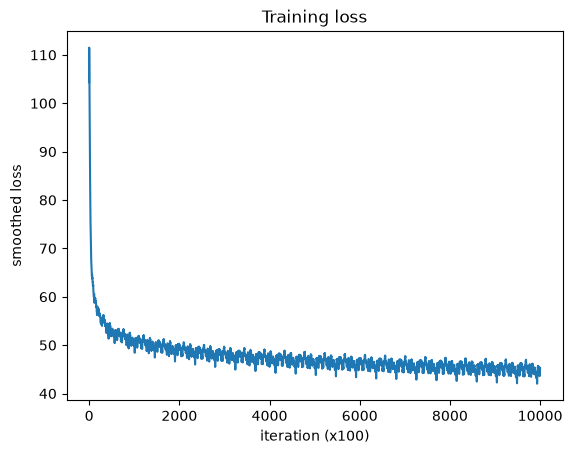

Finished 1000000  iterations.
Ase trind God,
But meearsbas thou shall SEAR Speis the no lords,
Inmous enceep the wand art withing have calft begised woed, swent.
nay are of have bolifus net me
unfounf'ded,
Oes with to compictted you.
Oldolive, ab treesin
To kinsan from lind thy heaventerect our coudined soul, of teed, The mark bongies, the for batthing.

KINGOL:
Led deed I arling, bill tull a what lugks in deould and.
 IFoy our houbmasser chreable lach
Thou with the not meronsoled,
, kit?

KING RICH:
What livine Comin;
As happighted toot may ames; I hath or rreed upon but pet of recasies Doom.

NORTIO:
When trat ueven, hore, is this e, huntaking genturisolter'd Ey the for than the cofa facker the there, I flean
Hashe.

BENVOLEO:
Witth sblost deall,
I dannead well, what I nou,- Goots weal upjuging,
Re;, brock;
He of the fasd;
I sent toal's ance a the all beswal,
How Heavy and it fant the calkid hath fur,
I mard! in comped the loven and, to fur:
May.

LEONS:
Thy saclot south.

LUCENWISB:

In [ ]:
import numpy as np
from scipy.special import softmax

###### DATA LOADING


with open('data/input.txt', 'r') as f:
    text = f.read()

    chars = sorted(set(text))
    char_to_idx = {ch: i for i, ch in enumerate(chars)}
    idx_to_char = {i: ch for i, ch in enumerate(chars)}

    data = np.array([char_to_idx[ch] for ch in text])

def chunk_data(data, T):

    n = (len(data)-1) // T

    inputs = []
    targets = []

    for i in range(n):
        index = i*T
        inp = data[index:(index+T)]
        tar = data[index+1:(index+1+T)]
        inputs.append(inp)
        targets.append(tar)

    return np.array(inputs), np.array(targets)

T = 25
#print(chunk_data(list('abcdefghijklmnopqrstuvwxyz'), 5))
inputs, targets = chunk_data(data, T)

###### PARAMETER INIT

V=len(chars)
H = 256
W_xh = np.random.randn(H,V) * 0.01
W_hh = np.random.randn(H,H) * 0.01
W_hy = np.random.randn(V,H) * 0.01

b_h = np.zeros(H)
b_y = np.zeros(V)

mem_W_xh = np.zeros((H,V))
mem_W_hh = np.zeros((H,H))
mem_W_hy = np.zeros((V,H))
mem_b_h = np.zeros(H)
mem_b_y = np.zeros(V)

###### FORWARD PASS

def one_hot_encode(char):
    temp = np.zeros(V)
    temp[char] = 1
    return temp

def forward_pass(input_chunk, target_chunk, h_prev):
    L = 0
    x = np.empty((T, V))
    h = np.empty((T+1, H))
    p = np.empty((T, V))
    h[0] = h_prev
    for t in range(T):
        x[t] = one_hot_encode(input_chunk[t])
        h[t+1] = np.tanh((W_xh @ x[t]) + (W_hh @ h[t]) + b_h)
        y = W_hy @ h[t+1] + b_y
        y_shifted = np.exp(y - np.max(y))
        p[t] = y_shifted / np.sum(y_shifted)
        L += -1 * np.log(p[t][target_chunk[t]])

    return L, x, h, p, h[T]

#L, x, h_cache, p, h_last = forward_pass(inputs[0], targets[0], np.zeros(H))

############ BACKWARD PASS

def backward_pass(x, h_cache, p, target_chunk):
    dW_xh = np.zeros((H,V))
    dW_hh = np.zeros((H,H))
    dW_hy = np.zeros((V,H))
    db_h = np.zeros(H)
    db_y = np.zeros(V)

    dh_next = np.zeros(H)
    dh = np.zeros((T, H))

    for t in range(T-1, -1, -1):
        dy = p[t].copy()
        dy[target_chunk[t]] -= 1
        dW_hy += np.outer(dy, h_cache[t+1])
        db_y += dy
        dh_t = np.transpose(W_hy) @ dy + dh_next
        dz = dh_t * (1 - h_cache[t+1] * h_cache[t+1])
        dW_xh += np.outer(dz, x[t])
        dW_hh += np.outer(dz, h_cache[t])
        db_h += dz
        dh_next = np.transpose(W_hh) @ dz

    return np.clip(dW_xh, -5, 5),\
           np.clip(dW_hh, -5, 5),\
           np.clip(dW_hy, -5, 5),\
           np.clip(db_h, -5, 5),\
           np.clip(db_y, -5, 5)

#dW_xh, dW_hh, dW_hy, db_h, db_y = backward_pass(x, h_cache, p, targets[0])

########## ADAGRAD 

def adagrad(dW_xh, dW_hh, dW_hy, db_h, db_y):
    global W_xh, W_hh, W_hy, b_h, b_y,mem_W_xh, mem_W_hh, mem_W_hy, mem_b_h, mem_b_y
    
    mem_W_xh += dW_xh ** 2
    mem_W_hh += dW_hh ** 2
    mem_W_hy += dW_hy ** 2
    mem_b_h  += db_h  ** 2
    mem_b_y  += db_y  ** 2

    learning_rate = 0.1
    epsilon = 1 * (10 ** (-8))

    W_xh -= learning_rate * dW_xh / (np.sqrt(mem_W_xh) + epsilon)
    W_hh -= learning_rate * dW_hh / (np.sqrt(mem_W_hh) + epsilon)
    W_hy -= learning_rate * dW_hy / (np.sqrt(mem_W_hy) + epsilon)
    b_h -= learning_rate * db_h / (np.sqrt(mem_b_h) + epsilon)
    b_y -= learning_rate * db_y / (np.sqrt(mem_b_y) + epsilon)

#################### SAVE THE DATA

def save_model(path, W_xh, W_hh, W_hy, b_h, b_y, char_to_idx, idx_to_char):
    np.savez(path,
             W_xh=W_xh, W_hh=W_hh, W_hy=W_hy,
             b_h=b_h, b_y=b_y,
             chars=np.array(list(char_to_idx.keys())))

######### TRAINING LOOP

import matplotlib.pyplot as plt

smooth_loss = -np.log(1.0/V) * T   # reasonable init value: expected loss at random init
loss_history = []

h_prev = np.zeros(H)
i = 0
num_iterations = 25000000 # or however long you want to train

for iteration in range(num_iterations):
    if i == 0:
        h_prev = np.zeros(H)

    L, x, h_cache, p, h_last = forward_pass(inputs[i], targets[i], h_prev)
    dW_xh, dW_hh, dW_hy, db_h, db_y = backward_pass(x, h_cache, p, targets[i])
    adagrad(dW_xh, dW_hh, dW_hy, db_h, db_y)
    h_prev = h_last

    smooth_loss = smooth_loss * 0.999 + L * 0.001
    if iteration % 100 == 0:
        loss_history.append(smooth_loss)
        print(f"iter {iteration}, loss {smooth_loss:.4f}")

    if iteration % 150000 == 0 and iteration > 0:
        save_model(f'checkpoint_H256_{iteration}.npz', W_xh, W_hh, W_hy, b_h, b_y, char_to_idx, idx_to_char)

    i += 1
    if i >= len(inputs):
        i = 0

save_model('model_checkpoint.npz', W_xh, W_hh, W_hy, b_h, b_y, char_to_idx, idx_to_char)

plt.plot(loss_history)
plt.xlabel('iteration (x100)')
plt.ylabel('smoothed loss')
plt.title('Training loss')
plt.show()

print("Finished", num_iterations, " iterations.")

#### LOAD DATA

def load_model(path):
    data = np.load(path)
    W_xh = data['W_xh']
    W_hh = data['W_hh']
    W_hy = data['W_hy']
    b_h = data['b_h']
    b_y = data['b_y']

    chars = sorted(data['chars'].tolist())
    char_to_idx = {ch: i for i, ch in enumerate(chars)}
    idx_to_char = {i: ch for i, ch in enumerate(chars)}

    return W_xh, W_hh, W_hy, b_h, b_y, char_to_idx, idx_to_char

#W_xh, W_hh, W_hy, b_h, b_y, char_to_idx, idx_to_char = load_model('model_checkpoint.npz')

####### RESULTS

seed_char = 'A'

x = one_hot_encode(char_to_idx[seed_char])
h = h_prev
characters = 5000
output = []

for i in range(characters):
    h = np.tanh(W_xh @ x + W_hh @ h + b_h)
    y = W_hy @ h + b_y
    p = softmax(y)
    new_char = np.random.choice(chars, p=p)
    output.append(str(new_char))
    x = one_hot_encode(char_to_idx[new_char])

print(seed_char + ''.join(output))